- K-Means
- Elbow Method
- K-Means++
- Hierarchical Clustering
- Agglomerative Clustering
- DBSCAN
- OPTICS
- Gaussian Mixture Model (GMM)
- Expectation-Maximization (EM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering,
    OPTICS
)

from sklearn.mixture import GaussianMixture

from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)

In [2]:
df = pd.read_csv("Data/big_mart_sales.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB
None


In [4]:
print(
    df.isnull().sum()
)

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [5]:
print(
    df.select_dtypes(
        include=["int64", "float64"]
    ).columns
)

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')


In [6]:
cluster_features = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year"
]

In [7]:
X_cluster = df[
    cluster_features
].copy()

display(
    X_cluster.head()
)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
0,9.30,0.016047,249.8092,1999
1,5.92,0.019278,48.2692,2009
2,17.50,0.016760,141.6180,1999
3,19.20,0.000000,182.0950,1998
4,8.93,0.000000,53.8614,1987


In [8]:
imputer = SimpleImputer(
    strategy="median"
)

X_imputed = imputer.fit_transform(
    X_cluster
)

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_imputed
)

print(
    X_scaled.shape
)

(8523, 4)


In [10]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

print(
    "Explained Variance:",
    pca.explained_variance_ratio_
)

Explained Variance: [0.26977544 0.25533169]


In [11]:
kmeans = KMeans(
    n_clusters=3,
    init="random",
    n_init=10,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [12]:
print(
    np.unique(kmeans_labels)
)

[0 1 2]


In [13]:
print(
    pd.Series(
        kmeans_labels
    ).value_counts().sort_index()
)

0    2947
1    2395
2    3181
Name: count, dtype: int64


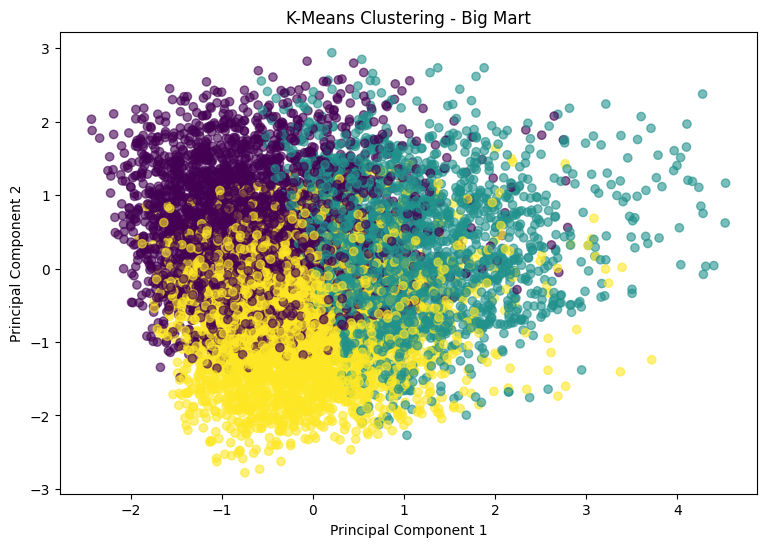

In [14]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "K-Means Clustering - Big Mart"
)

plt.show()

In [15]:
centers = kmeans.cluster_centers_

centers_pca = pca.transform(
    scaler.inverse_transform(
        centers
    )
)

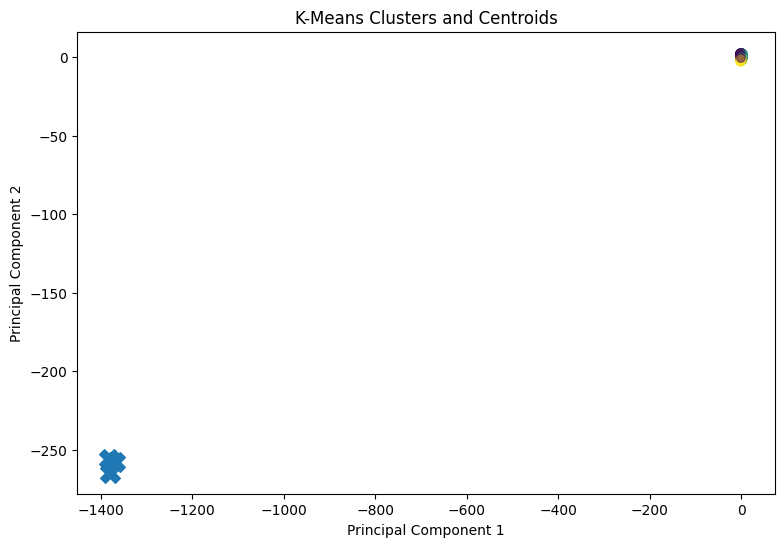

In [16]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    alpha=0.5
)

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "K-Means Clusters and Centroids"
)

plt.show()

In [17]:
inertia = []

K_range = range(
    2,
    11
)

for k in K_range:

    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    model.fit(
        X_scaled
    )

    inertia.append(
        model.inertia_
    )

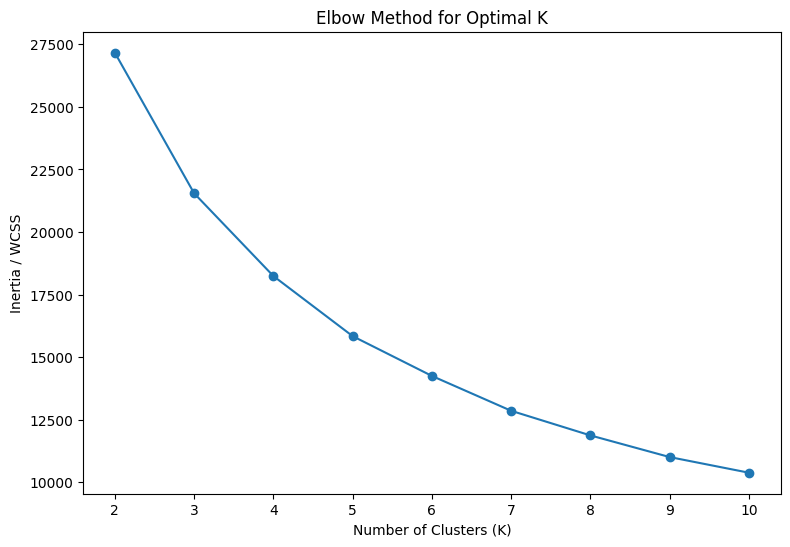

In [18]:
plt.figure(figsize=(9, 6))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Inertia / WCSS"
)

plt.title(
    "Elbow Method for Optimal K"
)

plt.xticks(
    list(K_range)
)

plt.show()

In [19]:
silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(
        score
    )

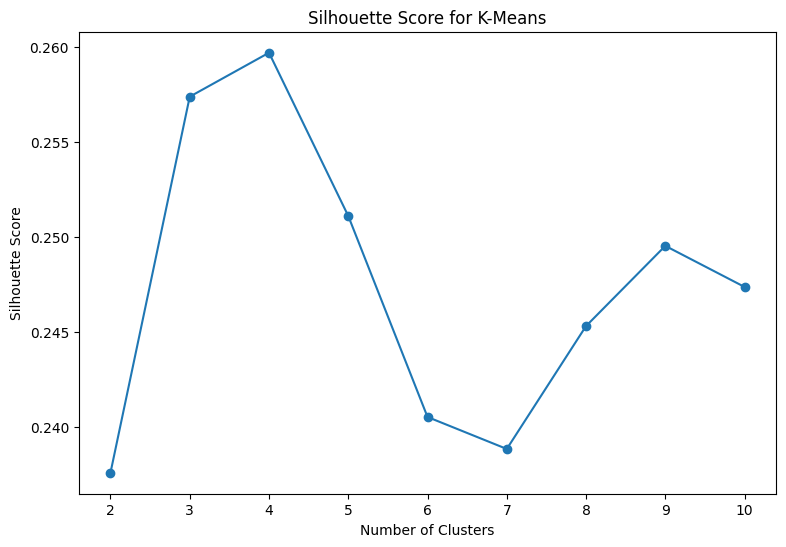

In [20]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Silhouette Score for K-Means"
)

plt.show()

In [21]:
kmeans_plus = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    random_state=42
)

kmeans_plus_labels = (
    kmeans_plus.fit_predict(
        X_scaled
    )
)

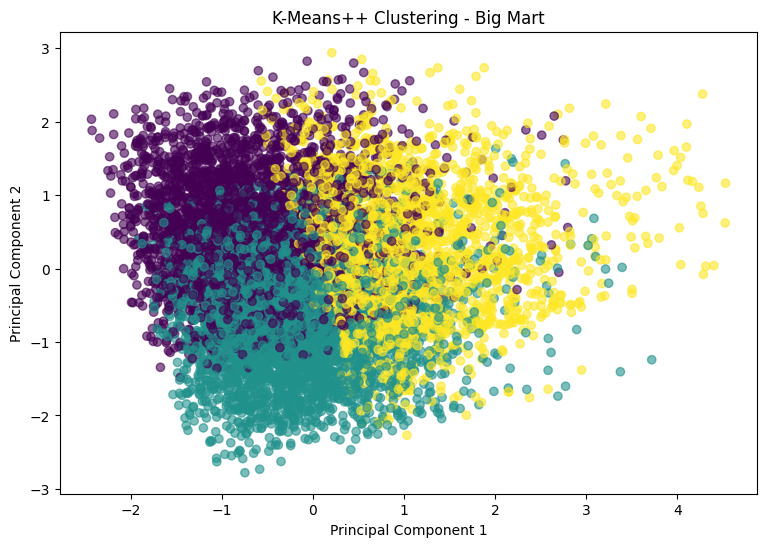

In [22]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_plus_labels,
    alpha=0.6
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "K-Means++ Clustering - Big Mart"
)

plt.show()

In [23]:
sample_size = min(
    300,
    len(X_scaled)
)

X_sample = X_scaled[
    :sample_size
]

In [24]:
linked = linkage(
    X_sample,
    method="ward"
)

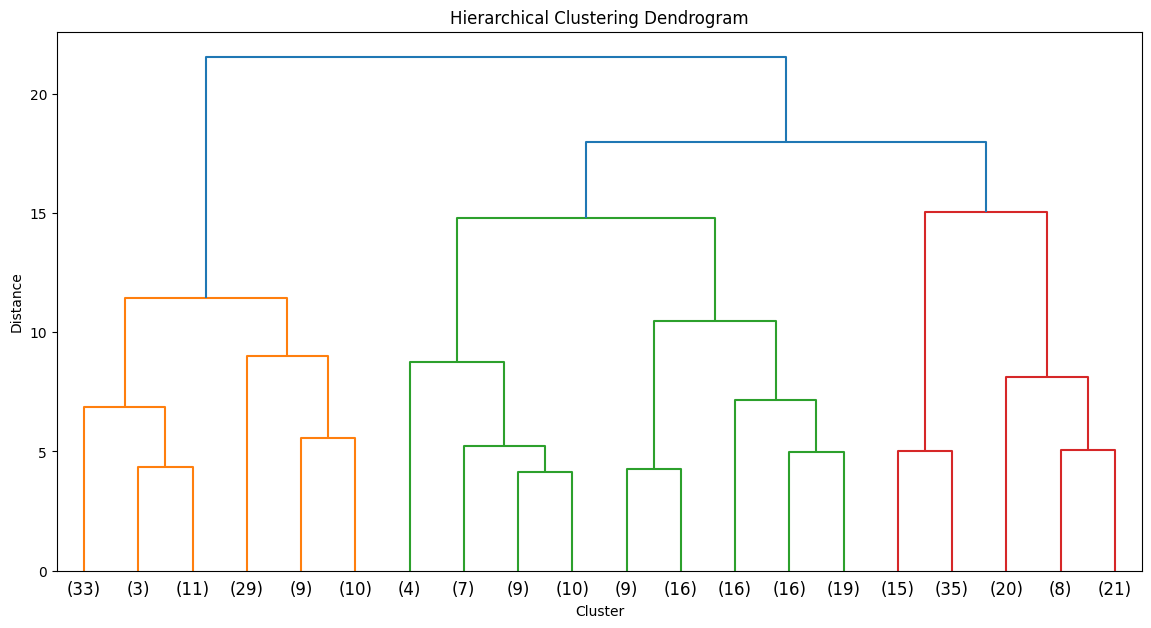

In [25]:
plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=20
)

plt.xlabel(
    "Cluster"
)

plt.ylabel(
    "Distance"
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.show()

In [26]:
agglomerative = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

agg_labels = (
    agglomerative.fit_predict(
        X_scaled
    )
)

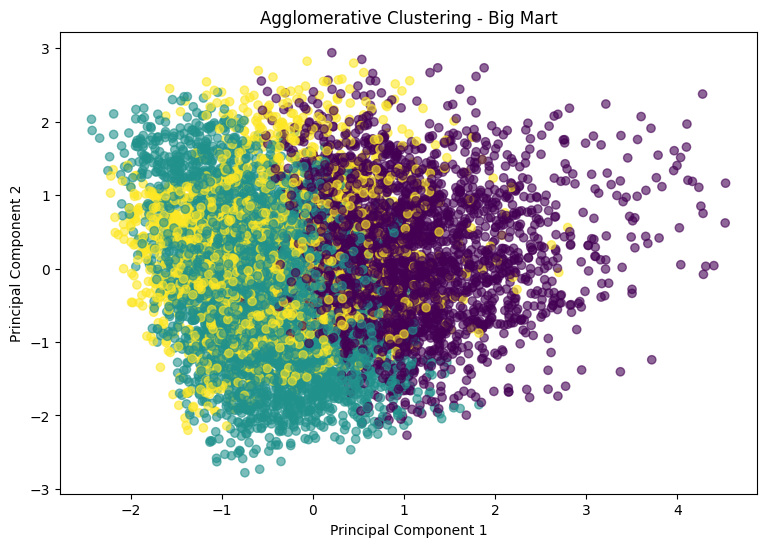

In [27]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=agg_labels,
    alpha=0.6
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "Agglomerative Clustering - Big Mart"
)

plt.show()

In [28]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

In [29]:
print(
    np.unique(dbscan_labels)
)

[-1  0  1  2]


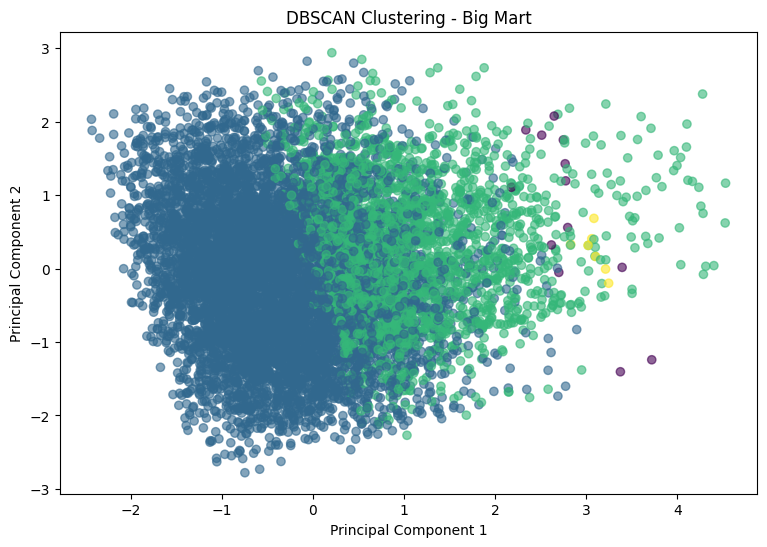

In [30]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    alpha=0.6
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "DBSCAN Clustering - Big Mart"
)

plt.show()

In [31]:
dbscan_counts = pd.Series(
    dbscan_labels
).value_counts().sort_index()

print(
    dbscan_counts
)

-1      13
 0    6108
 1    2395
 2       7
Name: count, dtype: int64


In [32]:
optics = OPTICS(
    min_samples=5,
    xi=0.05,
    min_cluster_size=0.05
)

optics_labels = optics.fit_predict(
    X_scaled
)

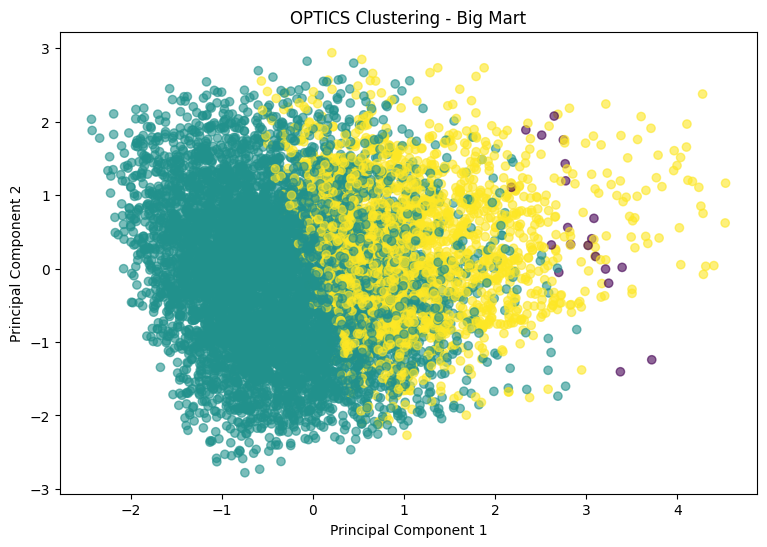

In [33]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=optics_labels,
    alpha=0.6
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "OPTICS Clustering - Big Mart"
)

plt.show()

In [34]:
ordering = optics.ordering_

reachability = optics.reachability_[
    ordering
]

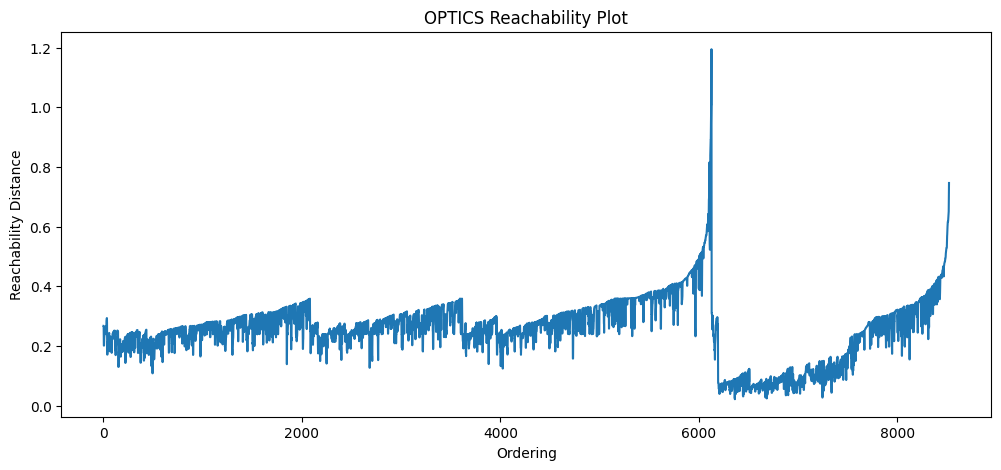

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(reachability)),
    reachability
)

plt.xlabel(
    "Ordering"
)

plt.ylabel(
    "Reachability Distance"
)

plt.title(
    "OPTICS Reachability Plot"
)

plt.show()

In [36]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

gmm.fit(
    X_scaled
)

GaussianMixture(n_components=3, random_state=42)

In [37]:
gmm_labels = gmm.predict(
    X_scaled
)

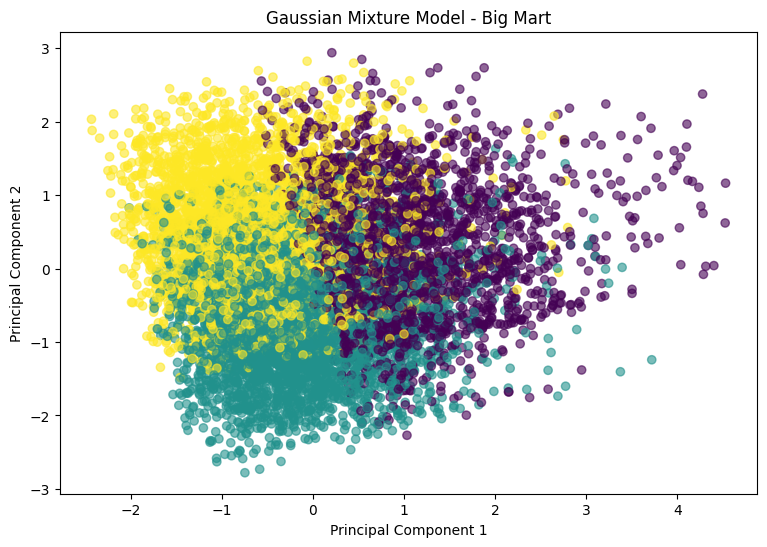

In [38]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels,
    alpha=0.6
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "Gaussian Mixture Model - Big Mart"
)

plt.show()

In [39]:
gmm_probability = gmm.predict_proba(
    X_scaled
)

print(
    gmm_probability[:5]
)

[[4.62189430e-041 9.91385481e-001 8.61451897e-003]
 [1.42084494e-127 9.99783179e-001 2.16821126e-004]
 [3.28946859e-040 2.19736434e-003 9.97802636e-001]
 [4.84299402e-034 2.16214780e-004 9.99783785e-001]
 [9.98676322e-001 1.31326523e-003 1.04124049e-005]]


In [40]:
print(
    "EM iterations:",
    gmm.n_iter_
)

EM iterations: 3


In [41]:
print(
    "Converged:",
    gmm.converged_
)

Converged: True


In [42]:
print(
    "Lower Bound:",
    gmm.lower_bound_
)

Lower Bound: -5.063950271352725


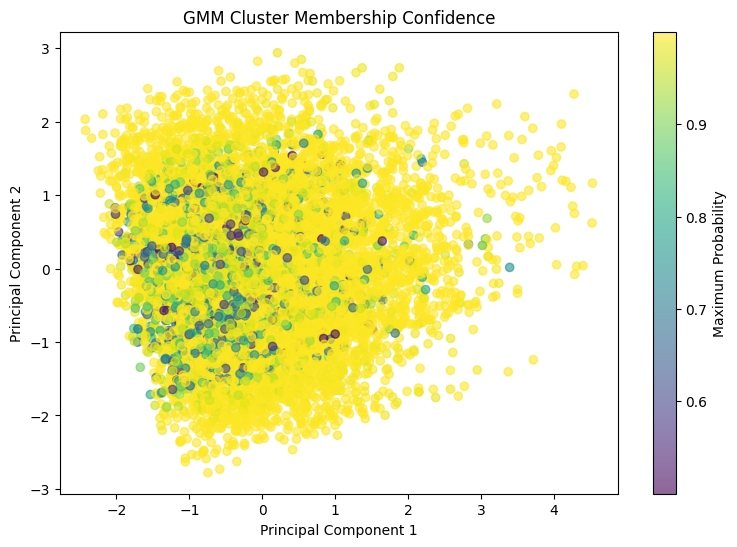

In [43]:
max_probability = (
    gmm_probability.max(axis=1)
)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=max_probability,
    alpha=0.6
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "GMM Cluster Membership Confidence"
)

plt.colorbar(
    label="Maximum Probability"
)

plt.show()

In [44]:
def evaluate_clustering(
    X,
    labels,
    name
):

    # Remove noise for density-based methods
    mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    unique_clusters = np.unique(
        labels_eval
    )

    if len(unique_clusters) < 2:

        return {
            "Algorithm": name,
            "Clusters": len(unique_clusters),
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan
        }

    silhouette = silhouette_score(
        X_eval,
        labels_eval
    )

    db = davies_bouldin_score(
        X_eval,
        labels_eval
    )

    ch = calinski_harabasz_score(
        X_eval,
        labels_eval
    )

    return {
        "Algorithm": name,
        "Clusters": len(unique_clusters),
        "Silhouette": silhouette,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch
    }

In [45]:
clustering_results = []

clustering_results.append(
    evaluate_clustering(
        X_scaled,
        kmeans_labels,
        "K-Means"
    )
)

clustering_results.append(
    evaluate_clustering(
        X_scaled,
        kmeans_plus_labels,
        "K-Means++"
    )
)

clustering_results.append(
    evaluate_clustering(
        X_scaled,
        agg_labels,
        "Agglomerative"
    )
)

clustering_results.append(
    evaluate_clustering(
        X_scaled,
        dbscan_labels,
        "DBSCAN"
    )
)

clustering_results.append(
    evaluate_clustering(
        X_scaled,
        optics_labels,
        "OPTICS"
    )
)

clustering_results.append(
    evaluate_clustering(
        X_scaled,
        gmm_labels,
        "Gaussian Mixture"
    )
)

In [46]:
clustering_results_df = pd.DataFrame(
    clustering_results
)

display(
    clustering_results_df
)

,Algorithm,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,0.257372,1.475455,2479.526411
1,K-Means++,3,0.257366,1.475485,2479.528074
2,Agglomerative,3,0.183278,1.737792,1729.367960
3,DBSCAN,3,0.222586,1.235265,1124.240119
4,OPTICS,2,0.239651,1.612321,2205.018325
5,Gaussian Mixture,3,0.257263,1.476114,2477.530783


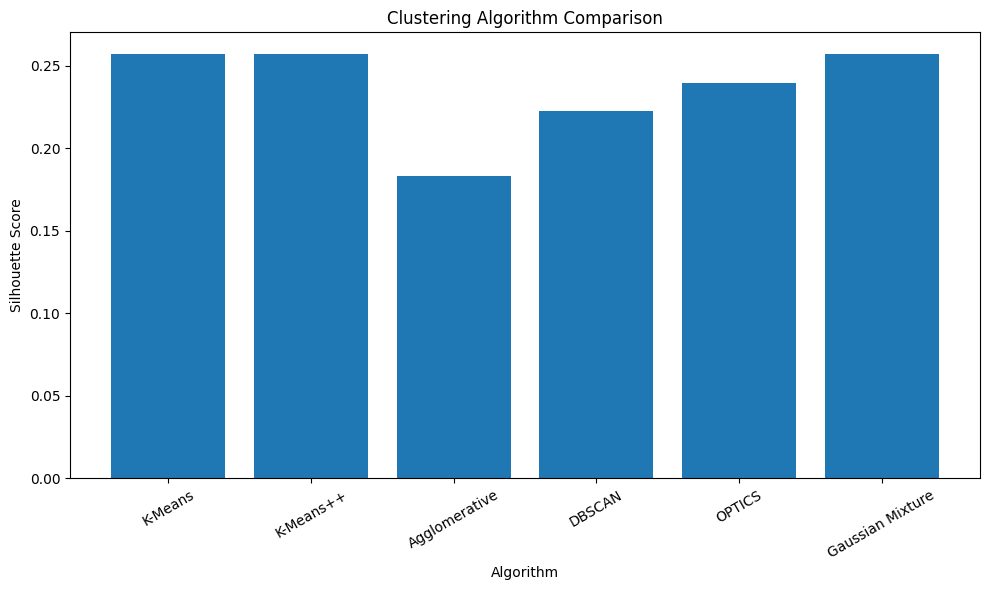

In [47]:
plt.figure(figsize=(10, 6))

plt.bar(
    clustering_results_df["Algorithm"],
    clustering_results_df["Silhouette"]
)

plt.xlabel(
    "Algorithm"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Clustering Algorithm Comparison"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()

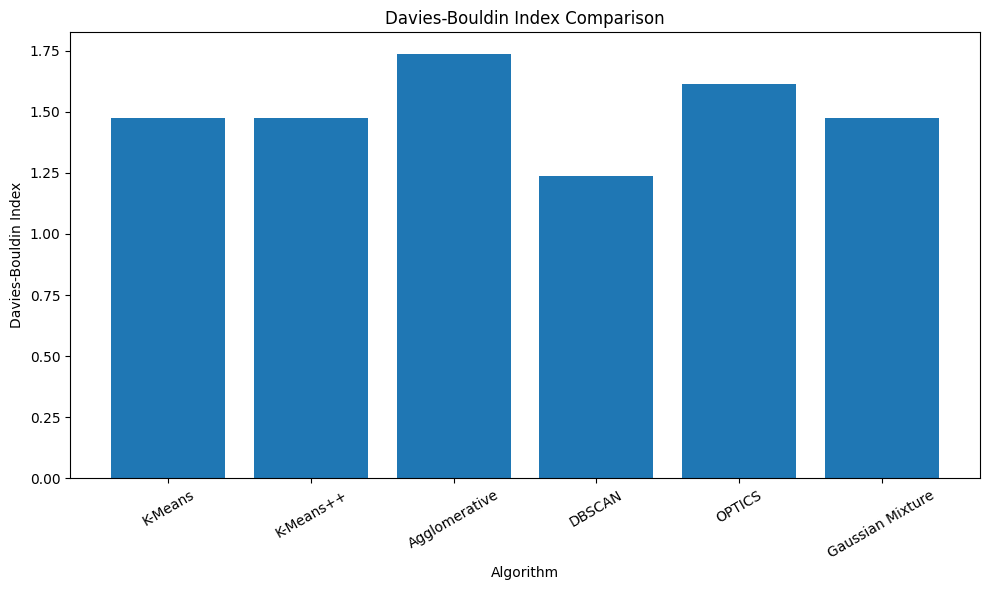

In [49]:
plt.figure(figsize=(10, 6))

plt.bar(
    clustering_results_df["Algorithm"],
    clustering_results_df["Davies-Bouldin"]
)

plt.xlabel(
    "Algorithm"
)

plt.ylabel(
    "Davies-Bouldin Index"
)

plt.title(
    "Davies-Bouldin Index Comparison"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()

In [50]:
df["KMeans_Cluster"] = kmeans_labels

In [51]:
display(
    df[
        [
            "Item_Identifier",
            "Item_Weight",
            "Item_Visibility",
            "Item_MRP",
            "Outlet_Establishment_Year",
            "KMeans_Cluster"
        ]
    ].head(20)
)

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,KMeans_Cluster
0,FDA15,9.300,0.016047,249.8092,1999,2
1,DRC01,5.920,0.019278,48.2692,2009,2
2,FDN15,17.500,0.016760,141.6180,1999,0
3,FDX07,19.200,0.000000,182.0950,1998,0
4,NCD19,8.930,0.000000,53.8614,1987,1
5,FDP36,10.395,0.000000,51.4008,2009,2
6,FDO10,13.650,0.012741,57.6588,1987,1
7,FDP10,NaN,0.127470,107.7622,1985,1
8,FDH17,16.200,0.016687,96.9726,2002,0
9,FDU28,19.200,0.094450,187.8214,2007,0


In [52]:
cluster_summary = df.groupby(
    "KMeans_Cluster"
)[
    [
        "Item_Weight",
        "Item_Visibility",
        "Item_MRP",
        "Item_Outlet_Sales"
    ]
].mean()

display(
    cluster_summary
)

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales
KMeans_Cluster,,,,
0,17.035562,0.063838,143.611156,2128.347068
1,13.006148,0.070122,140.430594,2411.809488
2,8.943554,0.065254,138.990296,2056.775504
